# LIMPIEZA DE DATOS

In [ ]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


# CARGA DE DATOS

In [14]:
df_flux = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_clean.csv"), sep=r",")
qc = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "qc.csv"), sep=r",")

print(f"df_flux: {df_flux.shape}")
print(f"qc: {qc.shape}")

df_flux: (660, 19)
qc: (690, 11)


In [15]:
# Lectura de parámetros desde config.xlsx
config = pd.read_excel(os.path.join(BASE_PATH, "NOTEBOOKS", "config.xlsx"), sheet_name="config", index_col="parameter")["value"]
fs = int(config["fs"])
window_minutes = int(config["window_minutes"])
samples_per_window = fs * 60 * window_minutes

print(f"fs={fs}, window_minutes={window_minutes}, samples_per_window={samples_per_window}")

fs=8, window_minutes=15, samples_per_window=7200


# DETECCIÓN DE OUTLIERS GLOBALES

Se detectan outliers en las variables agregadas por ventana usando el método Hampel (basado en MAD). Las ventanas con outliers se marcan con un flag sin eliminar ni modificar los datos.

In [16]:
cols_limpieza_global = [
    "flux_O2",
    "mean_O2",
    "mean_vz"
]

cols_limpieza_global = [
    c for c in cols_limpieza_global
    if c in df_flux.columns
]

In [17]:
def detectar_outliers_hampel_global(df, cols, factor=3):
    df_out = df.copy()
    resumen = []

    for col in cols:
        serie = df_out[col]

        mediana = serie.median()
        mad = np.median(np.abs(serie - mediana))

        if mad == 0 or np.isnan(mad):
            df_out[f"{col}_outlier_global"] = False
            continue

        umbral = factor * 1.4826 * mad
        mascara = np.abs(serie - mediana) > umbral

        df_out[f"{col}_outlier_global"] = mascara

        resumen.append({
            "variable": col,
            "mediana": mediana,
            "mad": mad,
            "umbral": umbral,
            "n_outliers": mascara.sum(),
            "pct_outliers": 100 * mascara.mean()
        })

    return df_out, pd.DataFrame(resumen)

In [18]:
df_global_diag, resumen_global = detectar_outliers_hampel_global(
    df_flux,
    cols=cols_limpieza_global,
    factor=3
)

display(resumen_global)

,variable,mediana,mad,umbral,n_outliers,pct_outliers
0,flux_O2,-7.464560,3.979172,17.698560,88,13.333333
1,mean_O2,221.368747,3.826812,17.020895,42,6.363636
2,mean_vz,-0.001339,0.000710,0.003159,24,3.636364


In [19]:
# Flag outlier global: True si es outlier en CUALQUIER variable agregada
cols_outlier = [c for c in df_global_diag.columns if c.endswith("_outlier_global")]
df_global_diag["flag_outlier_global"] = df_global_diag[cols_outlier].any(axis=1)

# Flag outlier ventana: True si la ventana tenía outliers en las muestras crudas (viene de qc.csv)
if "has_outliers" in qc.columns and "window_id" in qc.columns:
    qc_outliers = qc[["window_id", "has_outliers"]].copy()
    qc_outliers["has_outliers"] = qc_outliers["has_outliers"].astype(bool)
    df_global_diag = df_global_diag.merge(qc_outliers, on="window_id", how="left")
    df_global_diag["flag_outlier_window"] = df_global_diag["has_outliers"].fillna(False).astype(bool)
    df_global_diag.drop(columns=["has_outliers"], inplace=True)
else:
    df_global_diag["flag_outlier_window"] = False
    print("⚠ Columna 'has_outliers' no encontrada en qc.csv")

n_global = df_global_diag["flag_outlier_global"].sum()
n_window = df_global_diag["flag_outlier_window"].sum()
n_total = len(df_global_diag)
print(f"flag_outlier_global:  {n_global} ({100*n_global/n_total:.1f}%) — outliers en variables agregadas")
print(f"flag_outlier_window:  {n_window} ({100*n_window/n_total:.1f}%) — ventanas con outliers en señal cruda")

# Eliminar columnas auxiliares por variable
df_flux_clean_global = df_global_diag.drop(columns=cols_outlier)
df_flux_clean_global.head()

flag_outlier_global:  136 (20.6%) — outliers en variables agregadas
flag_outlier_window:  322 (48.8%) — ventanas con outliers en señal cruda


,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vx,mean_vy,...,mean_speed,mean_O2,mean_temp,valid_flux_window,flux_status,mean_pres,std_pres,flux_smooth,flag_outlier_global,flag_outlier_window
0,0,13.125009,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-1.714890,3.480262,...,4.071525,219.341074,14.859783,True,ok,1482.007222,4.667272,-6.351335,False,False
1,1,13.375009,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-1.702691,4.693565,...,5.161068,220.214211,14.832664,True,ok,1496.564576,5.315008,-6.745481,False,False
2,2,13.625009,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-1.457192,4.596101,...,4.948867,220.537457,14.821121,True,ok,1513.696097,5.783879,-6.619435,False,False
3,3,13.875009,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.720594,4.239672,...,4.422528,220.398051,14.816509,True,ok,1531.393618,5.371816,-6.799723,False,False
4,4,14.125009,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.909696,3.509688,...,3.791829,220.429227,14.806283,True,ok,1550.554493,5.584106,-6.911006,False,False


# FLAGS DE CALIDAD

Se marcan ventanas sospechosas sin eliminar ni modificar datos:
- **`flag_outlier_global`**: la ventana tiene al menos un valor outlier (Hampel/MAD) en alguna de las variables agregadas (flux_O2, mean_O2, mean_vz).
- **`flag_outlier_window`**: la ventana contenía muestras individuales atípicas en la señal cruda (O2/vz a 8 Hz), detectadas en NB1.
- **`flag_flux_positivo`**: el flujo acumulado de O2 es positivo (producción neta), inusual en sedimentos marinos.
- **`flag_vel_baja`**: el módulo medio de la velocidad (sqrt(vx²+vy²+vz²)) es muy bajo, posible sensor atascado o sin flujo real.

In [20]:
# Flags de calidad (no eliminan datos, solo marcan)
df_flux_clean_global["flag_flux_positivo"] = df_flux_clean_global["accumulated_flux_O2"] > 0
df_flux_clean_global["flag_vel_baja"] = df_flux_clean_global["mean_speed"] < 0.005  # Módulo medio de velocidad xyz muy bajo

# Resumen
n_total = len(df_flux_clean_global)
n_flux_pos = df_flux_clean_global["flag_flux_positivo"].sum()
n_vel_baja = df_flux_clean_global["flag_vel_baja"].sum()
n_ambos = (df_flux_clean_global["flag_flux_positivo"] & df_flux_clean_global["flag_vel_baja"]).sum()

print(f"Total ventanas: {n_total}")
print(f"  flag_flux_positivo: {n_flux_pos} ({100*n_flux_pos/n_total:.1f}%)")
print(f"  flag_vel_baja:      {n_vel_baja} ({100*n_vel_baja/n_total:.1f}%)")
print(f"  ambos flags:        {n_ambos} ({100*n_ambos/n_total:.1f}%)")

Total ventanas: 660
  flag_flux_positivo: 92 (13.9%)
  flag_vel_baja:      0 (0.0%)
  ambos flags:        0 (0.0%)


# GUARDADO DE DATOS

In [22]:
# Eliminar ventanas con flujo acumulado positivo antes de guardar
n_antes = len(df_flux_clean_global)
df_flux_clean_global = df_flux_clean_global[~df_flux_clean_global["flag_flux_positivo"]].copy()
n_eliminadas = n_antes - len(df_flux_clean_global)
print(f"Ventanas eliminadas (flux positivo): {n_eliminadas} ({100*n_eliminadas/n_antes:.1f}%)")

output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_flux.csv")
df_flux_clean_global.to_csv(output_path, index=False)
print(f"Datos guardados en: {output_path}")
print(f"Filas: {len(df_flux_clean_global)}, Columnas: {len(df_flux_clean_global.columns)}")

Ventanas eliminadas (flux positivo): 92 (13.9%)
Datos guardados en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\DATA\PROCESSED\df_flux.csv
Filas: 568, Columnas: 23


# ANÁLISIS

Responde a los puntos metodológicos y de resultados:
- Ventanas con spikes detectadas y corregidas (interpolación Hampel).
- % de ventanas recuperadas vs descartadas.
- Comparativa clean vs master para ver la ganancia.

In [23]:
df_flux_master = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_master.csv"))
df_flux_clean_nb = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_clean.csv"))

n_total_ventanas = len(qc)

# Ventanas con spikes (outliers en O2 detectados por Hampel)
n_con_spikes = int(qc["has_outliers"].sum()) if "has_outliers" in qc.columns else 0

# Ventanas donde se interpoló O2 (se corrigió al menos una muestra)
n_interpoladas = int((qc["n_interpolated_O2"] > 0).sum()) if "n_interpolated_O2" in qc.columns else 0

pct_con_spikes = 100 * n_con_spikes / n_total_ventanas if n_total_ventanas > 0 else 0
pct_interpoladas = 100 * n_interpoladas / n_total_ventanas if n_total_ventanas > 0 else 0


print("=" * 55)
print("RESUMEN DE RECUPERACIÓN")
print("=" * 55)
print(f"Total ventanas procesadas:          {n_total_ventanas}")
print(f"Ventanas con spikes O2 (Hampel):    {n_con_spikes} ({pct_con_spikes:.1f}%)")
print(f"Ventanas con interpolación aplicada:{n_interpoladas} ({pct_interpoladas:.1f}%)")

# No se gana nada exactamente porque los datos que hay en master no se pierden


RESUMEN DE RECUPERACIÓN
Total ventanas procesadas:          690
Ventanas con spikes O2 (Hampel):    335 (48.6%)
Ventanas con interpolación aplicada:59 (8.6%)


## COMPARACIÓN FLUJO MASTER vs CLEAN

Evalúa si la corrección por interpolación de spikes altera significativamente 
el flujo bentónico estimado. Se comparan las 57 ventanas con spikes en O₂ 
que tienen flujo calculado en ambas versiones (master y clean).

Ventanas con spikes (O2 o vz): 322
Correlación: r = 0.9995, p = 0.00e+00
Diferencia mediana: 0.011 mmol/m²/día


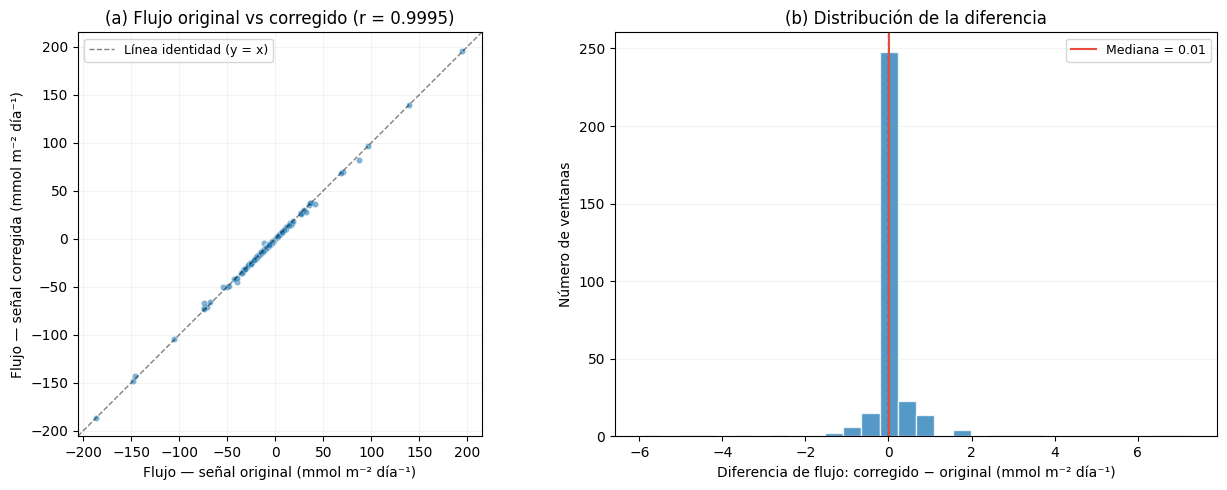

In [24]:
# ============================================================
# Flujo master vs clean — impacto de la corrección
# ============================================================
df_flux_master = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_master.csv"))
df_flux_clean_nb = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_clean.csv"))

# Merge: flujo clean vs master + info de spikes
cmp = df_flux_clean_nb[["window_id", "flux_O2"]].rename(columns={"flux_O2": "flux_clean"}).merge(
    df_flux_master[["window_id", "flux_O2"]].rename(columns={"flux_O2": "flux_master"}), on="window_id"
).merge(
    qc[["window_id", "n_outliers_O2", "n_outliers_vz"]], on="window_id", how="left"
)

# Ventanas con spikes en O2 o vz
sp = cmp[(cmp["n_outliers_O2"] > 0) | (cmp["n_outliers_vz"] > 0)].copy()
sp["diff"] = sp["flux_clean"] - sp["flux_master"]

# Stats
r, p = pearsonr(sp["flux_clean"], sp["flux_master"])
mediana_diff = sp["diff"].median()
print(f"Ventanas con spikes (O2 o vz): {len(sp)}")
print(f"Correlación: r = {r:.4f}, p = {p:.2e}")
print(f"Diferencia mediana: {mediana_diff:.3f} mmol/m²/día")

# ── Figura 2 paneles ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel (a): Scatter flux_master vs flux_clean ---
ax = axes[0]
ax.scatter(sp["flux_master"], sp["flux_clean"], s=20, alpha=0.6, color="#2980b9", edgecolors="white", linewidths=0.3)

# Línea identidad
lims = [min(sp["flux_master"].min(), sp["flux_clean"].min()) * 1.1,
        max(sp["flux_master"].max(), sp["flux_clean"].max()) * 1.1]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Línea identidad (y = x)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Flujo — señal original (mmol m⁻² día⁻¹)")
ax.set_ylabel("Flujo — señal corregida (mmol m⁻² día⁻¹)")
ax.set_title(f"(a) Flujo original vs corregido (r = {r:.4f})")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.15)
ax.set_aspect("equal")

# --- Panel (b): Distribución de diferencias ---
ax2 = axes[1]
ax2.hist(sp["diff"], bins=30, color="#2980b9", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax2.axvline(mediana_diff, color="#e74c3c", linestyle="-", linewidth=1.5, 
            label=f"Mediana = {mediana_diff:.2f}")
ax2.set_xlabel("Diferencia de flujo: corregido − original (mmol m⁻² día⁻¹)")
ax2.set_ylabel("Número de ventanas")
ax2.set_title("(b) Distribución de la diferencia")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.15, axis="y")

plt.tight_layout()

## RESULTADO DE LA LIMPIEZA POR VENTANA

Resumen del efecto de la corrección de spikes (MAD-Hampel) aplicada en NB1 sobre O₂ y vz.
Se muestra: (a) proporción de ventanas afectadas, (b) distribución del número de puntos corregidos.


Total ventanas con flujo calculado: 660 (de 690 en NB1)
  Sin corrección:       338 (51.2%)
  Con corrección en O₂: 57 (8.6%) — media: 144.9 spikes/ventana
  Con corrección en vz: 294 (44.5%) — media: 6.6 spikes/ventana
  En ambas variables:   29 (4.4%)


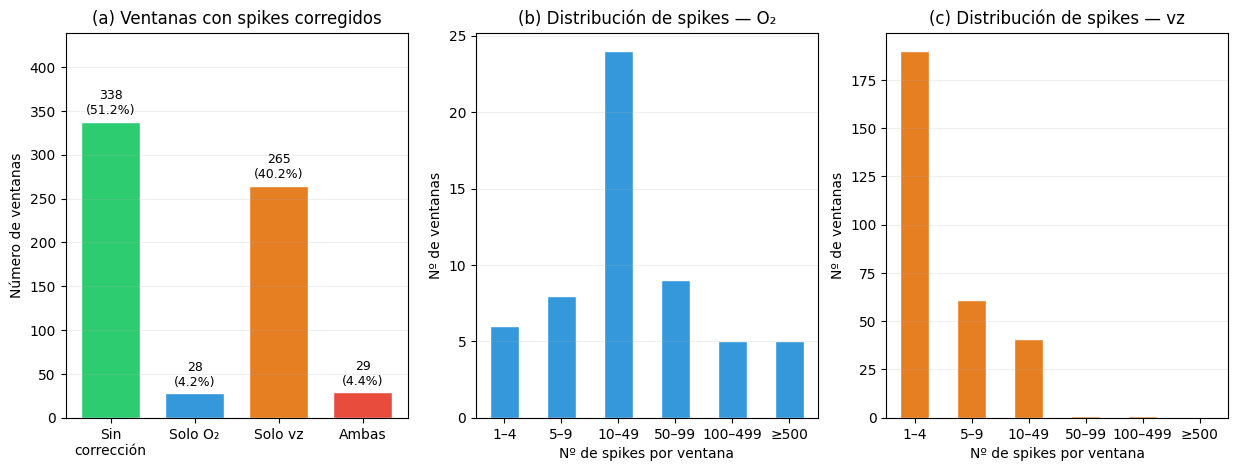

In [25]:
# ============================================================
# Incidencia de la corrección de spikes
# ============================================================

# Filtrar qc para quedarse solo con las ventanas que tienen flujo calculado
qc_flux = qc[qc["window_id"].isin(df_flux["window_id"])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel (a): Proporción de ventanas con/sin corrección ---
ax = axes[0]
n_total_qc = len(qc_flux)
n_corr_O2 = int((qc_flux["n_outliers_O2"] > 0).sum())
n_corr_vz = int((qc_flux["n_outliers_vz"] > 0).sum())
n_sin_corr = int(((qc_flux["n_outliers_O2"] == 0) & (qc_flux["n_outliers_vz"] == 0)).sum())
n_ambas = int(((qc_flux["n_outliers_O2"] > 0) & (qc_flux["n_outliers_vz"] > 0)).sum())

categorias = ["Sin\ncorrección", "Solo O₂", "Solo vz", "Ambas"]
valores = [
    n_sin_corr,
    n_corr_O2 - n_ambas,
    n_corr_vz - n_ambas,
    n_ambas
]
colores = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
bars = ax.bar(categorias, valores, color=colores, edgecolor="white", width=0.7)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val}\n({100*val/n_total_qc:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Número de ventanas")
ax.set_title("(a) Ventanas con spikes corregidos")
ax.set_ylim(0, max(valores) * 1.3)
ax.grid(True, alpha=0.2, axis="y")

# --- Panel (b): Distribución de spikes por ventana en O2 ---
ax = axes[1]
o2_spikes = qc_flux.loc[qc_flux["n_outliers_O2"] > 0, "n_outliers_O2"]
if len(o2_spikes) > 0:
    bins_o2 = [1, 5, 10, 50, 100, 500, o2_spikes.max() + 1]
    labels_o2 = ["1–4", "5–9", "10–49", "50–99", "100–499", "≥500"]
    cats_o2 = pd.cut(o2_spikes, bins=bins_o2, labels=labels_o2, right=False)
    cats_o2.value_counts().sort_index().plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_xlabel("Nº de spikes por ventana")
ax.set_ylabel("Nº de ventanas")
ax.set_title("(b) Distribución de spikes — O₂")
ax.grid(True, alpha=0.2, axis="y")
ax.tick_params(axis="x", rotation=0)

# --- Panel (c): Distribución de spikes por ventana en vz ---
ax = axes[2]
vz_spikes = qc_flux.loc[qc_flux["n_outliers_vz"] > 0, "n_outliers_vz"]
if len(vz_spikes) > 0:
    bins_vz = [1, 5, 10, 50, 100, 500, max(vz_spikes.max() + 1, 501)]
    labels_vz = ["1–4", "5–9", "10–49", "50–99", "100–499", "≥500"]
    cats_vz = pd.cut(vz_spikes, bins=bins_vz, labels=labels_vz, right=False)
    cats_vz.value_counts().sort_index().plot(kind="bar", ax=ax, color="#e67e22", edgecolor="white")
ax.set_xlabel("Nº de spikes por ventana")
ax.set_ylabel("Nº de ventanas")
ax.set_title("(c) Distribución de spikes — vz")
ax.grid(True, alpha=0.2, axis="y")
ax.tick_params(axis="x", rotation=0)


# Resumen numérico
print(f"\nTotal ventanas con flujo calculado: {n_total_qc} (de {len(qc)} en NB1)")
print(f"  Sin corrección:       {n_sin_corr} ({100*n_sin_corr/n_total_qc:.1f}%)")
print(f"  Con corrección en O₂: {n_corr_O2} ({100*n_corr_O2/n_total_qc:.1f}%) — media: {qc_flux.loc[qc_flux['n_outliers_O2']>0, 'n_outliers_O2'].mean():.1f} spikes/ventana")
print(f"  Con corrección en vz: {n_corr_vz} ({100*n_corr_vz/n_total_qc:.1f}%) — media: {qc_flux.loc[qc_flux['n_outliers_vz']>0, 'n_outliers_vz'].mean():.1f} spikes/ventana")
print(f"  En ambas variables:   {n_ambas} ({100*n_ambas/n_total_qc:.1f}%)")

## EJEMPLO DE SPIKE EN O₂

Selecciona una ventana con un número moderado de spikes en O₂ y genera una figura
que superpone la señal original (master) con la señal corregida (clean), marcando
los puntos anómalos detectados por el filtro MAD-Hampel.

Ventana seleccionada: 395 (41 spikes en O₂)
Guardada en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\..\..\MEMORIA\img/fig_ejemplo_spike_o2.pdf


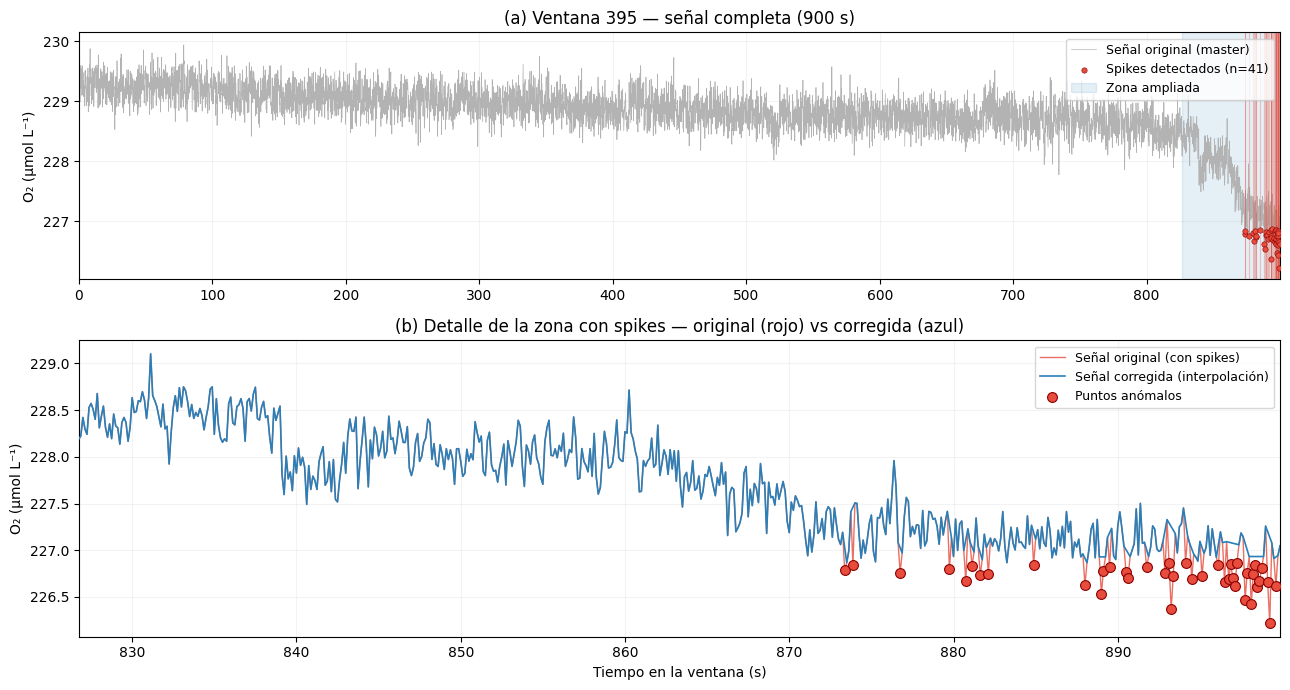

In [ ]:
# ============================================================
# Ejemplo de spike en O2 — original vs corregida
# ============================================================

# Seleccionar ventana con nº moderado de spikes (10-50) para que sea visualmente clara
candidatas = qc[(qc["n_outliers_O2"] >= 10) & (qc["n_outliers_O2"] <= 50)]
if len(candidatas) == 0:
    candidatas = qc[qc["n_outliers_O2"] > 0]
target_window = int(candidatas.iloc[len(candidatas) // 2]["window_id"])
n_spikes_target = int(qc.loc[qc["window_id"] == target_window, "n_outliers_O2"].values[0])
print(f"Ventana seleccionada: {target_window} ({n_spikes_target} spikes en O₂)")

# Leer datos per-sample de esa ventana
df_clean_all = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_clean.csv"))
dc = df_clean_all[df_clean_all["window_id"] == target_window].copy().reset_index(drop=True)

df_master_all = pd.read_csv(os.path.join(BASE_PATH, "DATA", "RAW", "df_master.csv"))
hour_min, hour_max = dc["hour"].min(), dc["hour"].max()
dm = df_master_all[(df_master_all["hour"] >= hour_min) & (df_master_all["hour"] <= hour_max)].copy().reset_index(drop=True)

# Eje temporal en segundos dentro de la ventana
n_samples = min(len(dc), len(dm))
t = np.arange(n_samples) / fs

o2_master = dm["O2"].values[:n_samples].astype(float)
o2_clean = dc["O2"].values[:n_samples].astype(float)
outlier_mask = dc["outlier_O2"].values[:n_samples].astype(bool)

# Índices de los spikes
spike_idx = np.where(outlier_mask)[0]

# ── Figura: 2 paneles ──
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [1, 1.2]})

# --- Panel (a): Ventana completa ---
ax = axes[0]
ax.plot(t, o2_master, color="0.7", linewidth=0.5, label="Señal original (master)")
# Marcar las zonas con spikes con franjas verticales
for idx in spike_idx:
    ax.axvline(t[idx], color="#e74c3c", alpha=0.3, linewidth=0.8)
ax.scatter(t[spike_idx], o2_master[spike_idx], color="#e74c3c", s=15, zorder=3,
           label=f"Spikes detectados (n={len(spike_idx)})", edgecolors="darkred", linewidths=0.4)
ax.set_ylabel("O₂ (μmol L⁻¹)")
ax.set_title(f"(a) Ventana {target_window} — señal completa (900 s)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.15)
ax.set_xlim(0, t[-1])

# Zona de zoom: centrada en el grupo principal de spikes
# Encontrar el cluster más denso de spikes
if len(spike_idx) > 1:
    # Buscar la zona con más spikes en un rango de ±50 muestras
    best_center = spike_idx[0]
    best_count = 0
    for si in spike_idx:
        count = np.sum(np.abs(spike_idx - si) < 200)  # ±200 muestras = ±25 s
        if count > best_count:
            best_count = count
            best_center = si
    zoom_center = best_center
else:
    zoom_center = spike_idx[0]

# Ventana de zoom: ±400 muestras = ±50 s alrededor del centro
zoom_half = 400  # muestras
zoom_start = max(0, zoom_center - zoom_half)
zoom_end = min(n_samples, zoom_center + zoom_half)

# Sombrear zona de zoom en panel (a)
ax.axvspan(t[zoom_start], t[zoom_end - 1], alpha=0.12, color="#2980b9", label="Zona ampliada")
ax.legend(loc="upper right", fontsize=9)

# --- Panel (b): Zoom ---
ax2 = axes[1]
t_zoom = t[zoom_start:zoom_end]
o2_m_zoom = o2_master[zoom_start:zoom_end]
o2_c_zoom = o2_clean[zoom_start:zoom_end]
mask_zoom = outlier_mask[zoom_start:zoom_end]

# Señal original completa (con spikes)
ax2.plot(t_zoom, o2_m_zoom, color="#e74c3c", linewidth=1.0, alpha=0.8,
         label="Señal original (con spikes)", zorder=2)
# Señal corregida (interpolada)
ax2.plot(t_zoom, o2_c_zoom, color="#2980b9", linewidth=1.2,
         label="Señal corregida (interpolación)", zorder=3)
# Marcar spikes con puntos grandes
spike_in_zoom = np.where(mask_zoom)[0]
if len(spike_in_zoom) > 0:
    ax2.scatter(t_zoom[spike_in_zoom], o2_m_zoom[spike_in_zoom],
                color="#e74c3c", s=50, zorder=4, edgecolors="darkred", linewidths=0.8,
                label="Puntos anómalos")

ax2.set_xlabel("Tiempo en la ventana (s)")
ax2.set_ylabel("O₂ (μmol L⁻¹)")
ax2.set_title(f"(b) Detalle de la zona con spikes — original (rojo) vs corregida (azul)")
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.15)
ax2.set_xlim(t_zoom[0], t_zoom[-1])

plt.tight_layout()

# Guardar
MEMORIA_IMG = os.path.join(BASE_PATH, "..", "..", "MEMORIA", "img")
os.makedirs(MEMORIA_IMG, exist_ok=True)
print(f"Guardada en: {MEMORIA_IMG}/fig_ejemplo_spike_o2.pdf")
plt.show()